In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

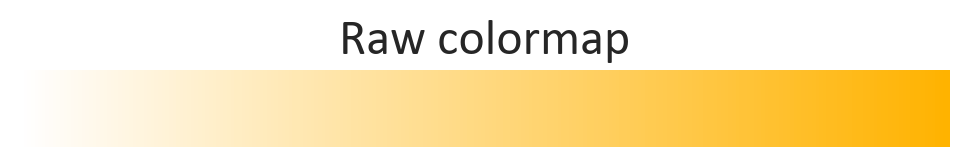

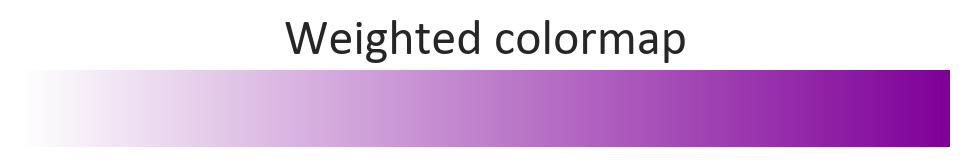

In [3]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/groot/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, transparent=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=transparent, **savefig_kwargs)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [5]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/storage/phd/neuroaging/data")
DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [6]:
metrics = ["adc", "gm_vol"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

all_data = {}
for metric in metrics:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    data = data[~data["subject_code"].isin(bad_subjects)]

    data["age_squared"] = data["age_at_scan"] ** 2
    data["sex"] = data["sex"].map({"M": 0, "F": 1})
    all_data[metric] = data

/tmp/ipykernel_2808035/1888622274.py:8: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_2808035/1888622274.py:8: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [7]:
metric_col = "volume" if metric == "gm_vol" else distribution_metric

In [8]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [9]:
def assign_weights_by_population(
    data: pd.DataFrame,
    population_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    range_start: str = "range_start",
    range_end: str = "range_end",
    total: str = "total",
) -> np.ndarray:
    """
    Post-stratification weights so the age distribution of *data*
    matches an external reference.

    - Accepts integer or float ages.
    - Handles boundary ages (include_lowest=True).
    - Leaves bins with zero sample untouched (weight=0 → later dropped).
    - Returns weights whose mean == 1 across *non-zero* weights.
    """

    # 1. Make sure population bins are well-formed
    pop = (
        population_df[[range_start, range_end, total]]
        .sort_values(range_start)
        .reset_index(drop=True)
    )
    if (pop[range_end] <= pop[range_start]).any():
        raise ValueError("Each range_end must exceed range_start.")
    if (pop[range_start].iloc[1:].values < pop[range_end].iloc[:-1].values).any():
        raise ValueError("Age bins overlap or are not strictly increasing.")

    # 2. Bin edges for pd.cut  →  [..., last_end]  (right-inclusive)
    bin_edges = pop[range_start].tolist() + [pop[range_end].iloc[-1]]

    # Population proportions (works for % or counts)
    pop_prop = pop[total] / pop[total].sum()

    # 3. Assign each participant to a bin
    sample_bins = pd.cut(
        data[age_col],
        bins=bin_edges,
        right=True,  # include right edge
        include_lowest=True,  # include first left edge
        labels=pop.index,  # integer labels 0..n-1
    )

    # 4. Sample distribution
    sample_counts = sample_bins.value_counts(sort=False)
    sample_prop = sample_counts / sample_counts.sum()

    # 5. Weight lookup  (population / sample)  — careful with zeros
    weight_lookup = pop_prop / sample_prop.replace(0, np.nan)

    # 6. Map to rows; bins with zero sample → NaN weight → drop later
    w = sample_bins.map(weight_lookup).to_numpy()

    # Assign *zero* weight (instead of 1) to rows that were NaN
    w = np.where(np.isnan(w), 0.0, w)

    # 7. Rescale so mean(weight > 0) == 1
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    return w

In [10]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [11]:
import numpy as np
import pandas as pd

def compute_joint_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    sex_col: str = "sex",
    male_label = 0,
    female_label = 1,
    start_col: str = "range_start",
    end_col: str = "range_end",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Computes joint post-stratification weights for Age and Sex so the sample
    matches an external census distribution.
    
    Parameters
    ----------
    sample_df : DataFrame with age and sex columns.
    pop_df    : DataFrame with [range_start, range_end, male, female].
    male_label/female_label : The values used in sample_df['sex'] (e.g., 0 and 1).
    cap       : Optional multiplier to truncate extreme weights.
    """
    # 1. Validation: Ensure all columns exist
    required_sample = [age_col, sex_col]
    required_pop = [start_col, end_col, "male", "female"]
    
    for col in required_sample:
        if col not in sample_df.columns:
            raise KeyError(f"Column '{col}' not found in sample_df. Available: {list(sample_df.columns)}")
    for col in required_pop:
        if col not in pop_df.columns:
            raise KeyError(f"Column '{col}' not found in pop_df. Available: {list(pop_df.columns)}")

    # 2. Tidy population table and convert to Long Format
    pop = pop_df.sort_values(start_col).copy()
    pop_long = pop.melt(
        id_vars=[start_col, end_col],
        value_vars=['male', 'female'],
        var_name='sex_str',
        value_name='pop_val'
    )
    
    # Map 'male'/'female' strings to the labels in your sample (0 and 1)
    pop_long[sex_col] = pop_long['sex_str'].map({'male': male_label, 'female': female_label})
    pop_long['prop_pop'] = pop_long['pop_val'] / pop_long['pop_val'].sum()
    
    # 3. Create Age Bins
    # edges define brackets: [0, 5, 10, ..., 90, 1000001]
    edges = sorted(list(pop[start_col].unique()) + [int(pop[end_col].max()) + 1])
    bin_labels = sorted(list(pop[start_col].unique()))
    
    sample = sample_df.copy()
    sample['age_bin_start'] = pd.cut(
        sample[age_col], 
        bins=edges, 
        labels=bin_labels, 
        right=False # standard for age: [start, end)
    )
    
    if sample['age_bin_start'].isna().any():
        print("Warning: Some participants fall outside the census age ranges.")

    # 4. Calculate Sample Proportions per (Age, Sex) cell
    sample_counts = sample.groupby(['age_bin_start', sex_col], observed=False).size().reset_index(name='n_sample')
    sample_counts['prop_sample'] = sample_counts['n_sample'] / sample_counts['n_sample'].sum()
    
    # Ensure types match for merging
    sample_counts['age_bin_start'] = sample_counts['age_bin_start'].astype(pop_long[start_col].dtype)
    
    # 5. Calculate Weight Factors (Population Proportion / Sample Proportion)
    weights_lookup = pd.merge(
        pop_long[[start_col, sex_col, 'prop_pop']],
        sample_counts,
        left_on=[start_col, sex_col],
        right_on=['age_bin_start', sex_col],
        how='left'
    )
    weights_lookup['weight_factor'] = weights_lookup['prop_pop'] / weights_lookup['prop_sample'].replace(0, np.nan)
    
    # 6. Map Weights back to individual sample rows
    sample['age_bin_start'] = sample['age_bin_start'].astype(pop_long[start_col].dtype)
    sample_with_weights = pd.merge(
        sample,
        weights_lookup[[start_col, sex_col, 'weight_factor']],
        left_on=['age_bin_start', sex_col],
        right_on=[start_col, sex_col],
        how='left'
    )
    
    w = sample_with_weights['weight_factor'].fillna(0).to_numpy()
    
    # 7. Apply optional cap and Rescale so mean weight = 1
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean() if any(w > 0) else 1.0
        w = np.clip(w, 0, cap * mean_pos)
        
    if any(w > 0):
        w = w / w.mean()
    else:
        print("Error: No matches found between sample and census. Weights are all zero.")

    if return_bin_table:
        return w, weights_lookup

    

    return w

In [12]:
# assign weights
for _, data in all_data.items():
    data["weight"], _ = compute_joint_poststrat_weights(
        data,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )

In [13]:
from statsmodels.formula.api import ols, wls
import statsmodels.formula.api as smf


def regional_models(region_data: pd.DataFrame, metric_col: str, model: str, covariates: list):
    """
    Fit a linear model to the data for each region.
    """
    # Fit the model
    if model == "ols":
        model = ols(f"{metric_col} ~ {' + '.join(covariates)}", data=region_data)
    elif model == "wls":
        model = wls(
            f"{metric_col} ~ {' + '.join(covariates)}",
            data=region_data,
            weights=region_data["weight"],
        )
    else:
        raise ValueError("Model must be either 'ols' or 'wls'.")

    # Fit the model
    results = model.fit()

    # Return the results
    return results

In [14]:
# from tqdm import tqdm

# # Set up dataframes to store results
# lin_unw, lin_w, quad_unw, quad_w = parcels.copy(), parcels.copy(), parcels.copy(), parcels.copy()

# covariates = ["age_at_scan", "sex"]
# if metric == "gm_vol":
#     covariates += ["tiv"]

# for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
#     region_data = data[data[region_col] == row[region_col]].copy()
#     region_data.rename(columns={metric_col: "value"}, inplace=True)
#     for results_df, model, is_quadratic in zip(
#         [lin_unw, lin_w, quad_unw, quad_w],
#         ["ols", "wls", "ols", "wls"],
#         [False, False, True, True],
#     ):
#         # Fit the model
#         if is_quadratic:
#             region_data["age_squared"] = region_data["age_at_scan"] ** 2
#             results = regional_models(region_data, "value", model, covariates + ["age_squared"])
#         else:
#             results = regional_models(region_data, "value", model, covariates)

#         # Store the results
#         results_df.loc[i, "model"] = results
#         results_df.loc[i, "pvalue"] = results.f_pvalue
#         results_df.loc[i, "r2"] = results.rsquared
#         results_df.loc[i, "r2_adj"] = results.rsquared_adj
#         results_df.loc[i, "n"] = len(region_data)
#         # if i == 405 and model == "wls" and is_quadratic:
#         #     a = results

In [48]:
# Tell the pipeline which side of the parabola is "structural stabilisation"
orientation = {  # feel free to expand
    "gm_vol": "max",  # concave-down expected
    "adc": "min",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}


def vertex_age(beta1, beta2):
    # Age at vertex of a quadratic beta0 + beta1*x + beta2*x^2.
    return -beta1 / (2 * beta2)


def stabilization_age(metric, betas, mean_age, *, age_min=18, age_max=75):
    b1, b2 = betas["age"], betas["age_sq"]
    
    # 1. Determine if the shape is 'biologically expected'
    is_u_shaped = b2 > 0
    if "vol" in metric:
        valid_shape = not is_u_shaped  # Expect Inverted-U (beta2 < 0)
    else:
        valid_shape = is_u_shaped      # Expect U-shape (beta2 > 0)

    if not valid_shape:
        # Return age_min as a default 'clipped' value instead of NaN 
        # to prevent downstream plotting/analysis errors
        return age_min, True, is_u_shaped

    # 2. Compute vertex (Corrected: add the mean_age shift)
    v_centered = -b1 / (2 * b2)
    age_star = mean_age + v_centered
    
    # 3. Clip and flag
    clipped = False
    if age_star < age_min:
        age_star, clipped = age_min, True
    elif age_star > age_max:
        age_star, clipped = age_max, True
        
    return age_star, clipped, is_u_shaped


In [ ]:
from tqdm import tqdm


regional_results = {}
mean_age_by_metric = {metric: data["age_at_scan"].mean() for metric, data in all_data.items()}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    mean_age = mean_age_by_metric[metric]

    covariates = ["age_c", "C(sex)"]
    if metric == "gm_vol":
        covariates += ["tiv"]

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        region_data = data[data[region_col] == row[region_col]].copy()
        region_data.rename(columns={metric_col: "value"}, inplace=True)
        region_data["age_c"] = region_data["age_at_scan"] - mean_age
        # region_data["age_c"] = region_data["age_at_scan"]
        region_data["age_c2"] = region_data["age_c"] ** 2

        lin_model = smf.wls(
            "value ~ " + " + ".join(covariates),
            data=region_data,
            weights=region_data["weight"],
        ).fit()
        quad_model = smf.wls(
            "value ~ " + " + ".join(covariates) + " + I(age_c ** 2)",
            data=region_data,
            weights=region_data["weight"],
        ).fit()

        f, p, _ = quad_model.compare_f_test(lin_model)
        delta_aic = quad_model.aic - lin_model.aic
        for results_df, model, is_quadratic in zip(
            [lin_w, quad_w],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "aic"] = model.aic
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "n"] = len(region_data)
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_c"]
            results_df.loc[i, "se_beta1"] = model.bse["age_c"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_c"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_c"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["I(age_c ** 2)"]
                results_df.loc[i, "se_beta2"] = model.bse["I(age_c ** 2)"]
                results_df.loc[i, "t_beta2"] = model.tvalues["I(age_c ** 2)"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_c ** 2)"]
                beta1, beta2 = (
                    model.params["age_c"],
                    model.params["I(age_c ** 2)"],
                )
                if delta_aic < -15:
                    # We only attempt to find a vertex if the quadratic is significantly better
                    age_star, clipped, u = stabilization_age(
                        metric,
                        {"age": quad_model.params["age_c"], "age_sq": quad_model.params["I(age_c ** 2)"]},
                        mean_age
                    )
                else:
                    # For linear or non-sig models, we default to the start of the lifespan
                    age_star, clipped, u = 18, True, (quad_model.params["I(age_c ** 2)"] > 0)
                results_df.loc[i, "age_star"] = age_star
                results_df.loc[i, "clipped"] = clipped
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "se_beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
                results_df.loc[i, "age_star"] = 18
                results_df.loc[i, "clipped"] = True

    regional_results[metric] = {
        "lin_w": lin_w,
        "quad_w": quad_w,
    }


Fitting models:   0%|          | 0/454 [00:00<?, ?it/s]

Fitting models: 100%|██████████| 454/454 [00:20<00:00, 21.74it/s]


In [49]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

for metric, results in regional_results.items():
    w_compare = parcels.copy()

    # do f test to compare between quadratic and linear models
    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        # collect models
        model1 = results["lin_w"].loc[i, "model"]
        model2 = results["quad_w"].loc[i, "model"]
        f, p, _ = model2.compare_f_test(model1)
        w_compare.loc[i, "f"] = f
        w_compare.loc[i, "pvalue"] = p
        w_compare.loc[i, "n"] = model1.nobs
        w_compare.loc[i, "AIC(lin)"] = model1.aic
        w_compare.loc[i, "AIC(quad)"] = model2.aic
        w_compare.loc[i, "delta_AIC"] = model2.aic - model1.aic
        w_compare["log(f)"] = np.log(w_compare["f"])
    # Save the comparison results
    w_compare["p_corrected"] = multipletests(w_compare["pvalue"], method="fdr_bh")[
        1
    ]  # Benjamini-Hochberg correction
    regional_results[metric]["w_compare"] = w_compare
    # do f test to compare between quadratic and linear models
    # model1 = lin_unw.loc[i, "model"]
    # model2 = quad_unw.loc[i, "model"]
    # f, p, _ = model2.compare_f_test(model1)
    # unw_compare.loc[i, "f"] = f
    # unw_compare.loc[i, "pvalue"] = p
    # unw_compare.loc[i, "n"] = model1.nobs
    # weighted

Fitting models: 100%|██████████| 454/454 [00:00<00:00, 1286.26it/s]


In [50]:
# regional_results["gm_vol"]["quad_w"].sort_values("age_star", ascending=False).head(50)
# a = regional_results["adc"]["quad_w"].copy()
# a[a["name"].str.contains("THA")].sort_values("age_star", ascending=False)
# a[a["clipped"] == False].hist()
# THA-DP-lh

In [51]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

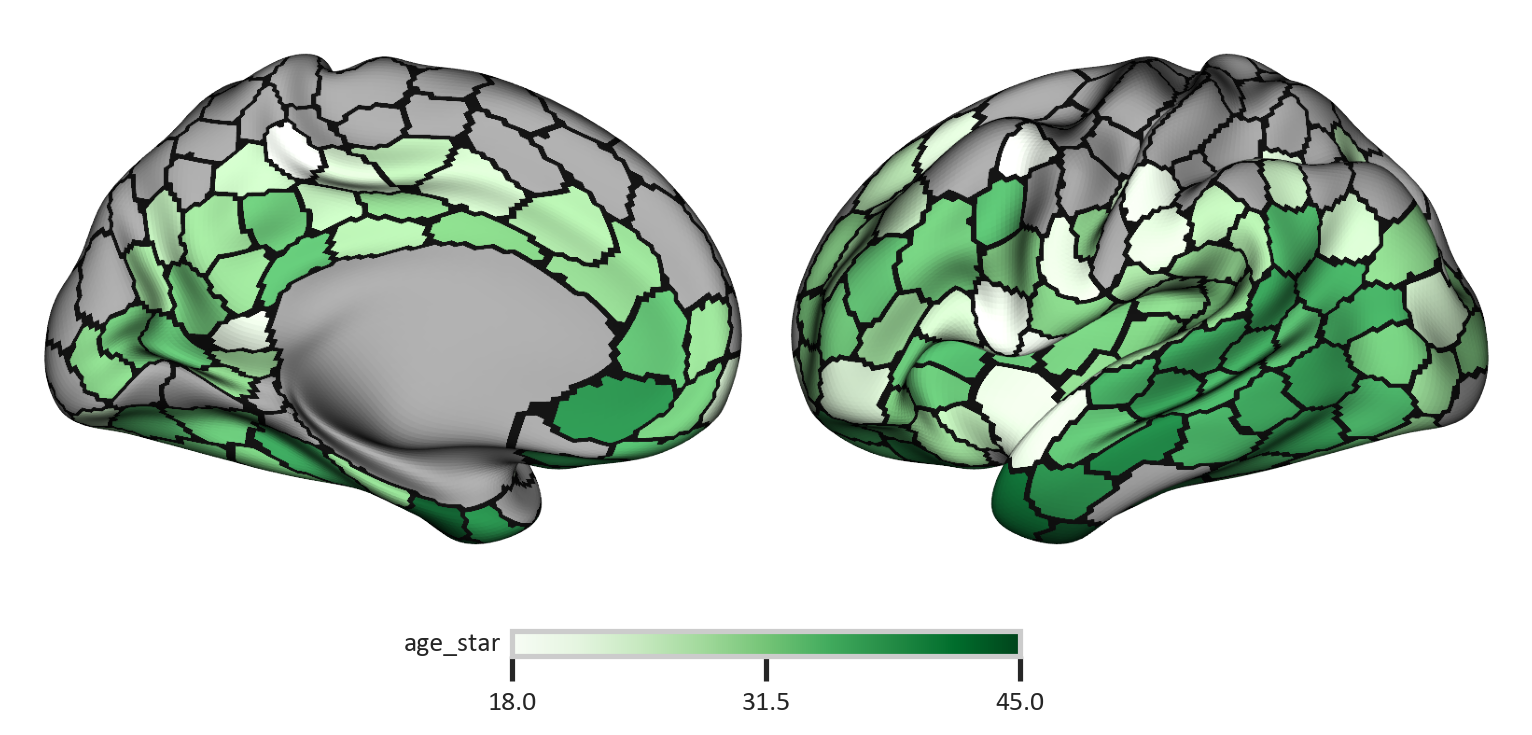

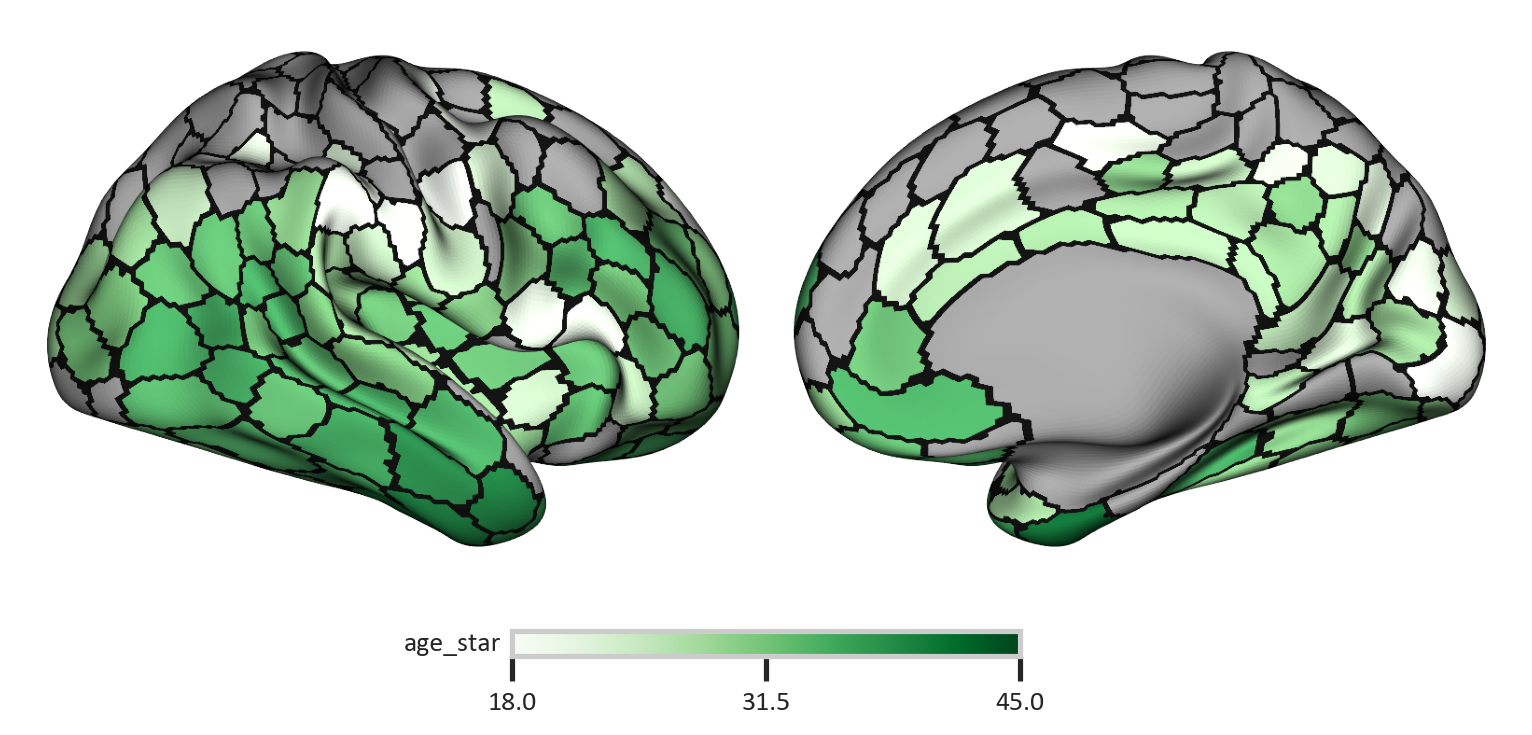

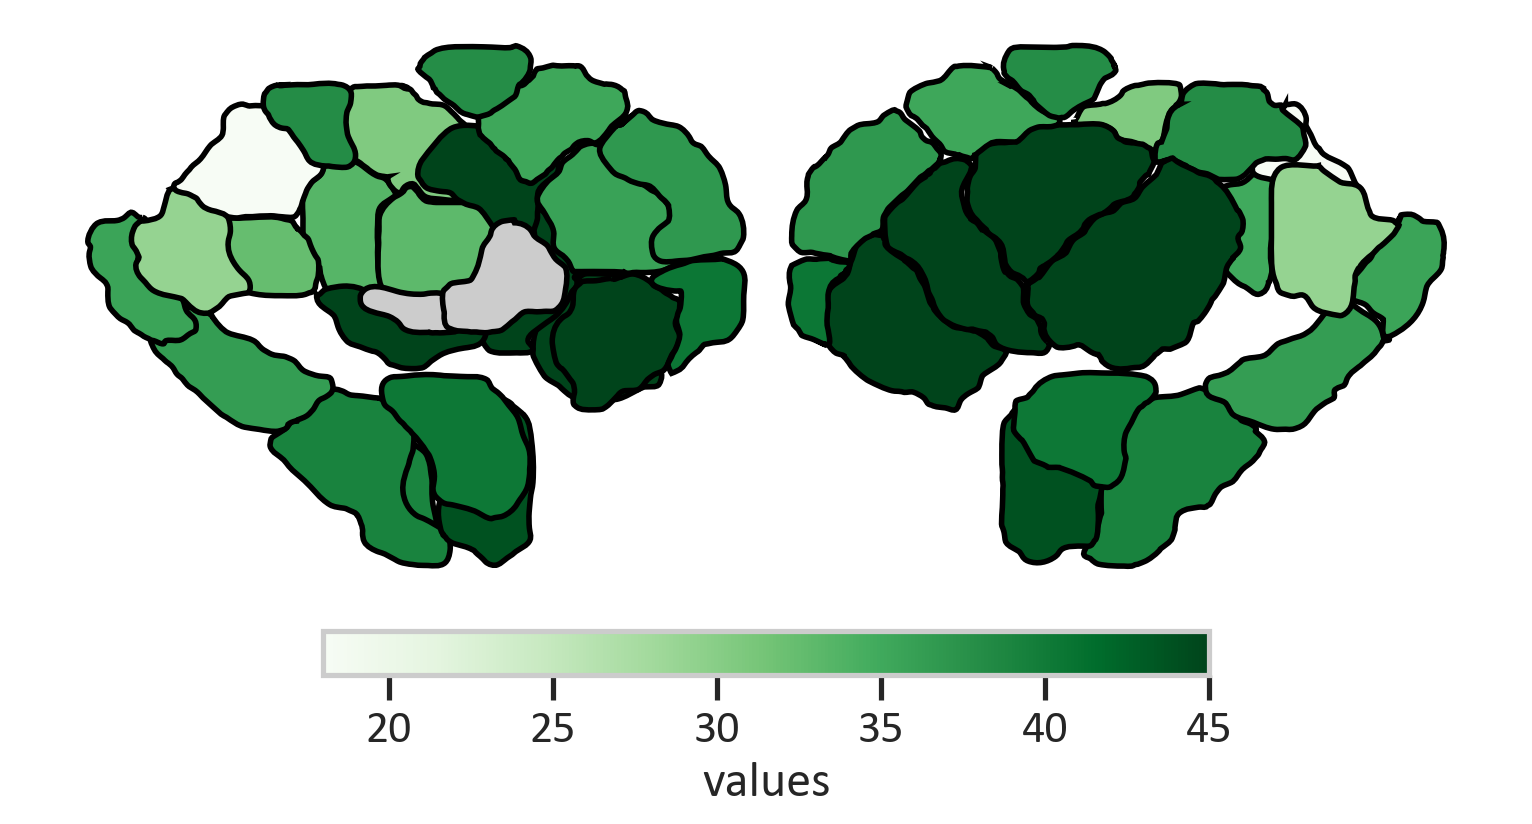

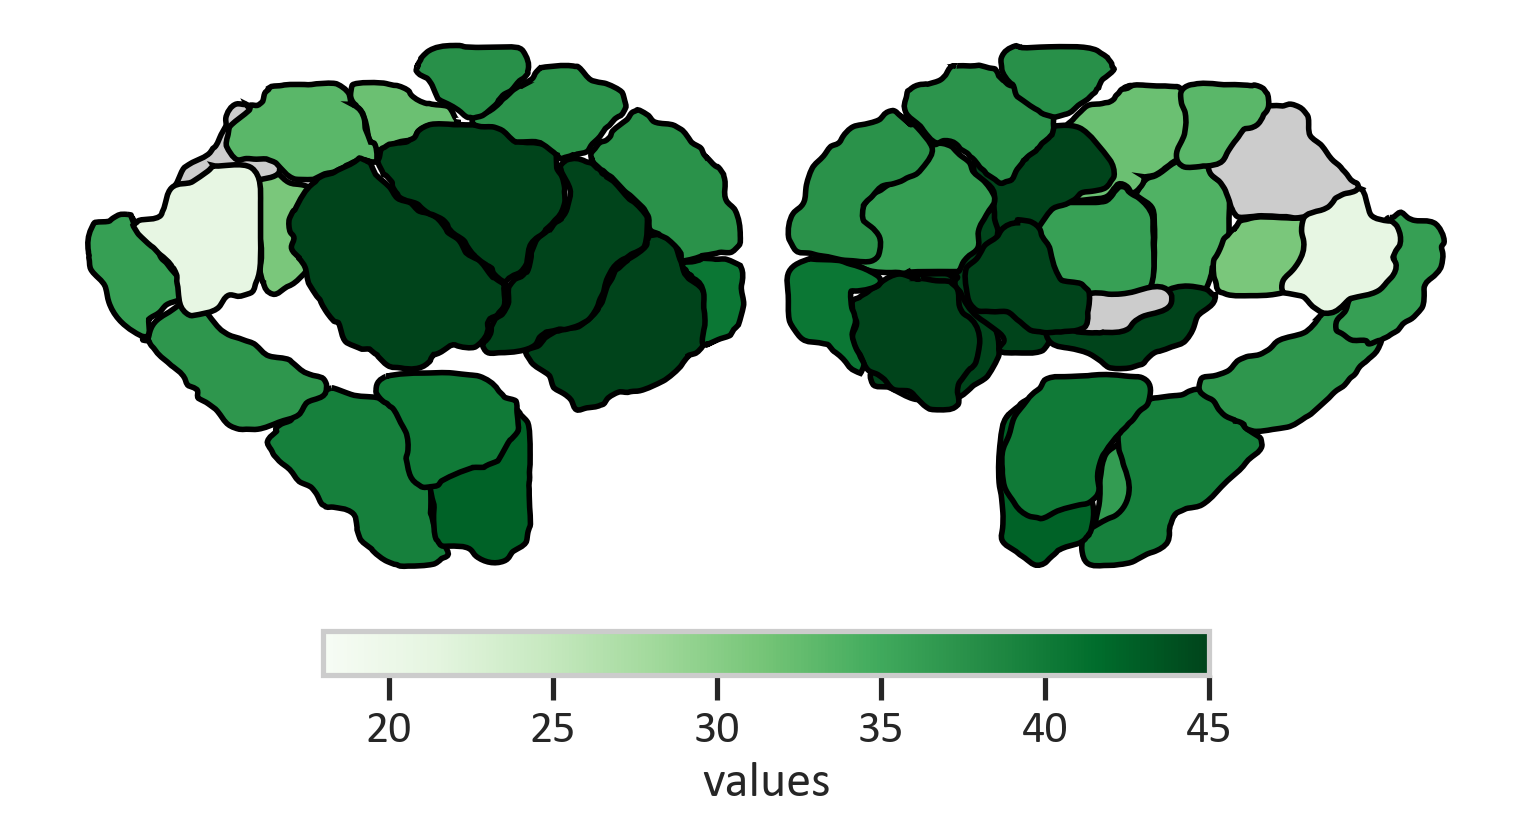

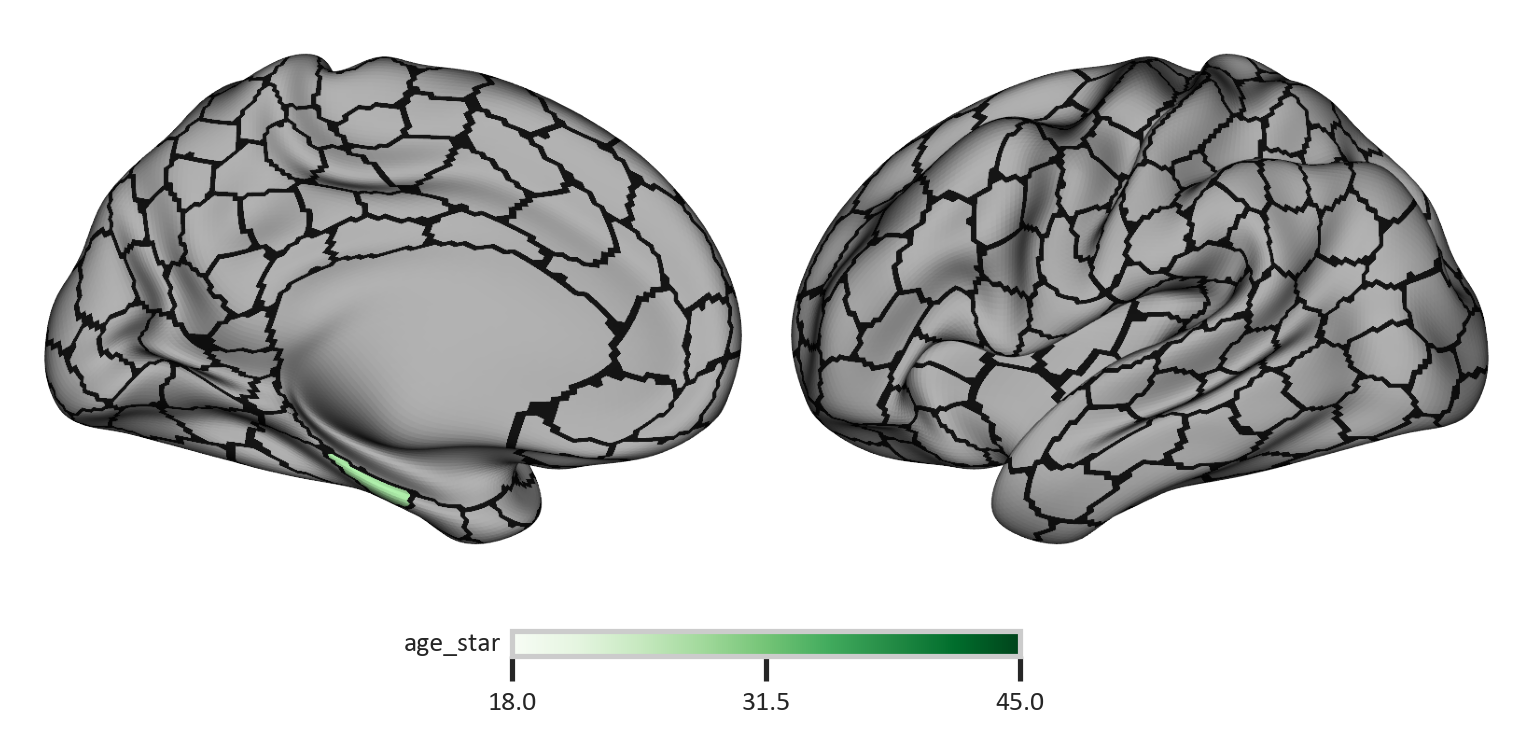

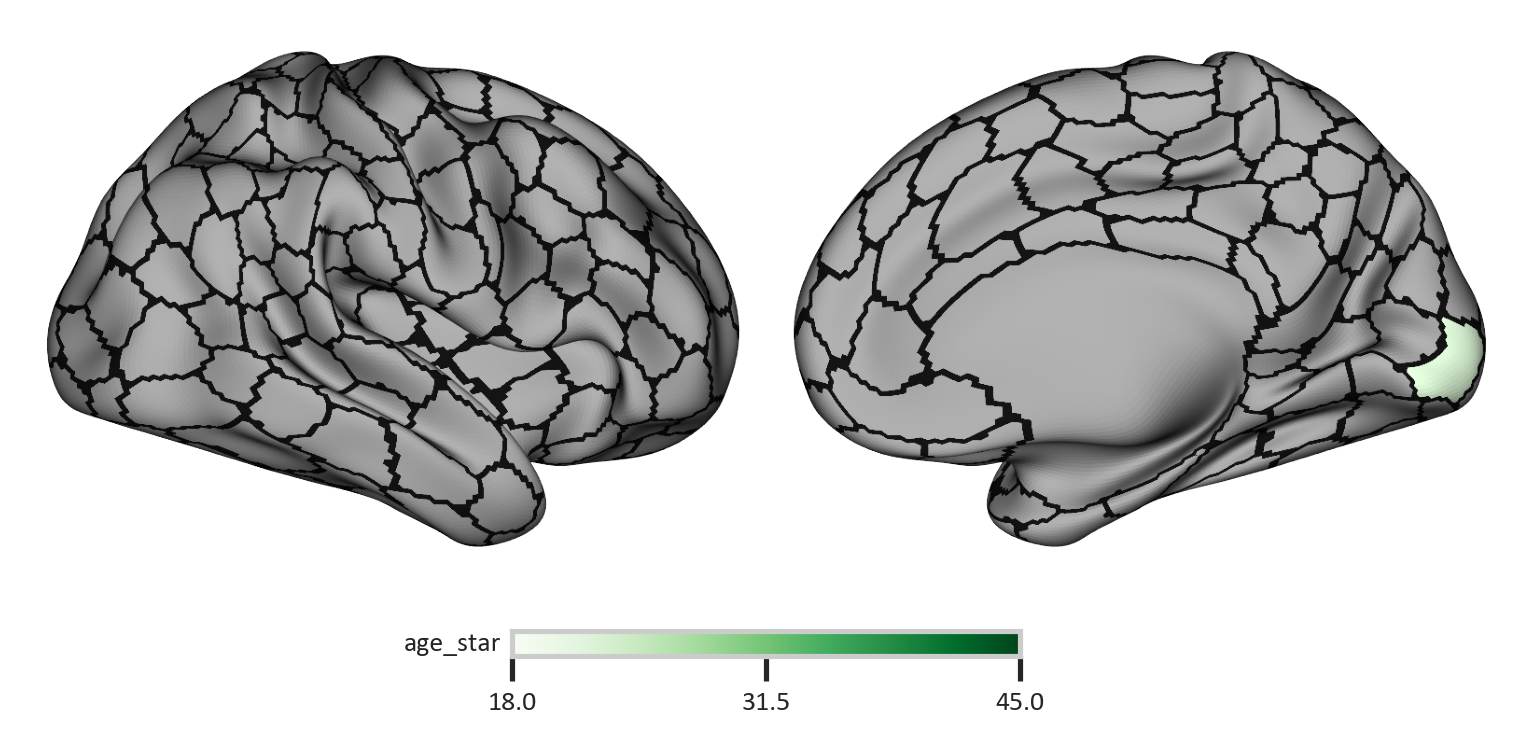

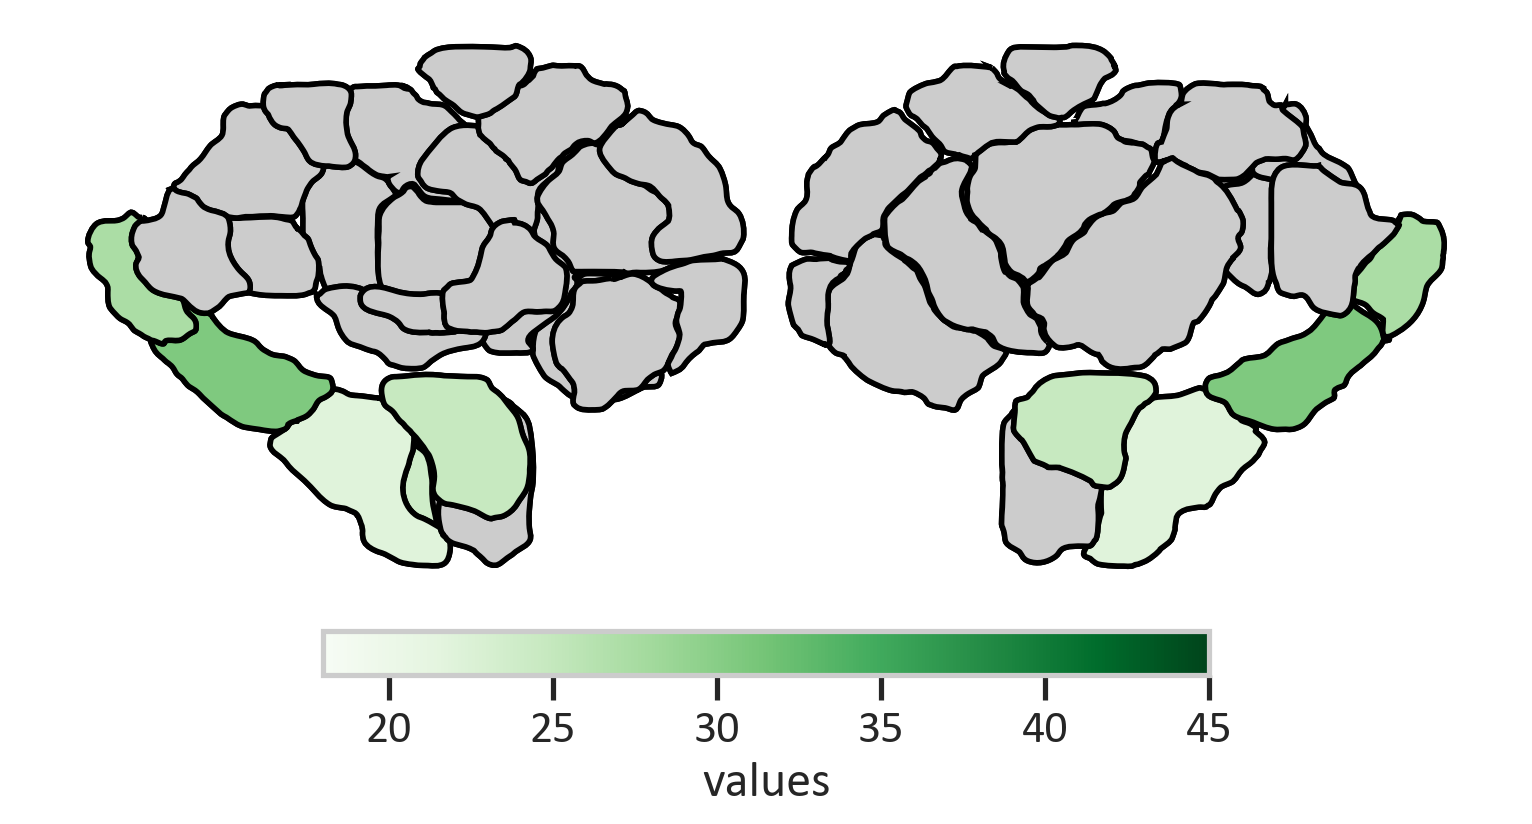

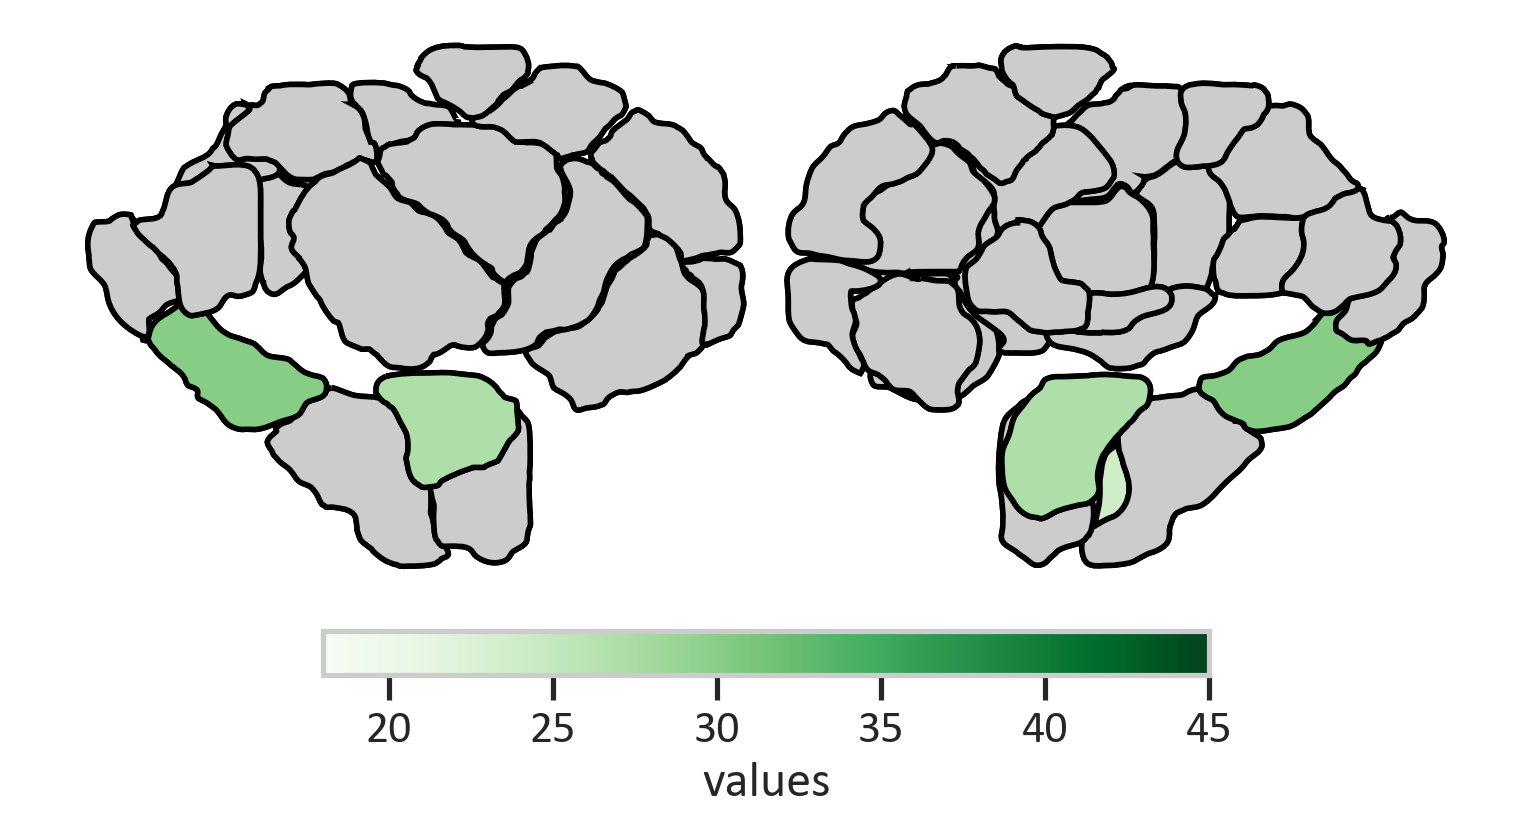

In [52]:
from subcortex_visualization.plotting import plot_subcortical_data
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0
vmin = 18
vmax = 45

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

for metric, results in regional_results.items():
    stab_df = results["quad_w"]
    vis_df = stab_df
    value_column = "age_star"

    value_map_lh = {}  # New: separate map for left hemisphere
    value_map_rh = {}  # New: separate map for right hemisphere

    for i, row in vis_df.iterrows():
        label = row[region_col]
        value = row[value_column]
        hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row
        # if (row["p_corrected"] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
        if row["clipped"]:
            value = np.nan
        # else:
        #     value = np.nan
        if "schaefer" in ATLAS:
            if label > int(ATLAS.split("_")[1]):
                value_map_subcortex["region"].append(label)
                value_map_subcortex["value"].append(value)
                value_map_subcortex["Hemisphere"].append(row["hemisphere"])
            else:
                if hemi_row == "L":
                    value_map_lh[label] = value
                elif hemi_row == "R":
                    value_map_rh[label] = value

    # Vectorize mapping for left and right hemispheres separately
    vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
    data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
    vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
    data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

    # Corrected loop for plotting each hemisphere independently
    for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
        ["left", "right"],  # The key for surfplot's dictionary
        [lh, rh],  # The surface object for the current hemisphere
        [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
        [lh_parc, rh_parc],  # The parcellation for the current hemisphere
    ):
        # ---------------------------------------------------------------------
        # 5.  BUILD THE PLOT
        # ---------------------------------------------------------------------
        pref_surf = {
            "surf_lh": hemi_surf_data if hemi_key == "left" else None,
            "surf_rh": hemi_surf_data if hemi_key == "right" else None,
        }
        p = Plot(
            **pref_surf,  # Unpack the surface dictionary
            views=(
                ["medial", "lateral"] if hemi_key == "left" else ["lateral", "medial"]
            ),  # Show both medial and lateral for this hemi
            size=(800, 300),  # px; change as needed
            zoom=1.6,
            layout="row",  # For a single hemisphere, row is fine
            mirror_views=False,  # Set to False, as we are plotting one hemi at a time
        )

        # ---- main data layer -------------------------------------------------
        # Pass only the data for the current hemisphere
        # The dictionary now contains only one key-value pair for the current hemisphere
        p.add_layer(
            {hemi_key: mapped_data},
            cmap="Greens",
            color_range=(vmin, vmax),  # Use symmetric range
            # norm=norm,  # Apply the symmetric normalization
            cbar_label=value_column,
            cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
        )
        # ---- outline layer ---------------------------------------------------
        p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

        fig = p.build(
            # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
        )  # Added cbar_kws for better cbar display

        # save figure
        savefig_nice(fig, OUTPUT_DIR / f"fig3_{metric}_{hemi_key}_{value_column}.png", dpi=400)

    subcort_df = pd.DataFrame(value_map_subcortex)
    if "schaefer" in ATLAS:
        subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


    for hemi in ["L", "R"]:

        fig = plot_subcortical_data(
            subcort_df,
            atlas="Melbourne_S3",
            show_legend=True,
            hemisphere=hemi,
            # cmap="Purples",
            cmap="Greens",
            line_color="black",
            line_thickness=2,
            vmin=vmin,
            vmax=vmax,
            show_figure=False,
        )

        # save figure
        savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)